In [2]:
import sys
from scipy.io import mmread
import os
import glob
import pandas as pd
import numpy as np
#from pandas_ods_reader import read_ods
from copy import deepcopy
import pprint
import json
import re
from datetime import datetime
import logging
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import HuberRegressor
from sklearn import preprocessing
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.distance import pdist
from scipy.spatial.distance import squareform
from sklearn.manifold import TSNE
from sklearn import metrics
from sklearn.cluster import DBSCAN
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from collections import Counter
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
import harmonypy as hm
from matplotlib.cm import ScalarMappable
from datetime import date
import mpld3
import hvplot.pandas
import holoviews as hv
from holoviews import opts
import panel as pn
import bokeh
from bokeh.resources import INLINE
from adjustText import adjust_text
from scipy.stats import mannwhitneyu, false_discovery_control, wilcoxon, pearsonr, spearmanr
import pygwalker as pyg
import matplotlib as mpl 
import PyPDF2
from PyPDF2 import PdfFileReader, PdfFileWriter, PdfReader, PdfWriter
from matplotlib.backends.backend_pdf import PdfPages
from pdf2image import convert_from_path
import fitz  # PyMuPDF


import dimorph_processing as dp
import cell_comparison as cc
import sex_stats as ss
import corr_analysis as ca
import violin_plot_per_pop as vp

today = str(date.today())

In [1]:
ca.stitch_heatmap_pdfs('/bigdata/isaac/top_gene_plots/',
                       '/bigdata/isaac/top_gene_plots/',
                       'top_genes',
                       None,
                       'quad',
                       )

NameError: name 'ca' is not defined

In [ ]:
gene_list = ['Socs2',
            'Uba52',
            'Cnot3',
            'Eid2',
            'Snhg6',
            'Cntn5',
            'Polr2l']


In [ ]:
gene_list

['Socs2', 'Uba52', 'Cnot3', 'Eid2', 'Snhg6', 'Cntn5', 'Polr2l']

In [3]:
df_orig = pd.read_feather('/bigdata/isaac/df_orig.feather')
meta_data_df = pd.read_json('/bigdata/isaac/gaba_glut_NN_combined_metadata_full_name.json')
#meta_data_df = meta_data_df.drop(['cluster_label'])
df = df_orig.reindex(columns=meta_data_df.columns)

IEG_list = []

with open('/bigdata/isaac/IEG_cluster.txt', 'r') as fh:
    for g in fh:
        IEG_list.append(g[:-1])

sex_gene_list = []

with open('/bigdata/isaac/sex_gene_list.txt', 'r') as fh:
    for g in fh:
        sex_gene_list.append(g[:-1])

#remove sex genes, IEG genes
df = dp.gene_remover(sex_gene_list,df)
df = dp.gene_remover(IEG_list,df)

#normalize
n_factor = 20000
col_sum = np.array(df.sum(axis=0))
#print (col_sum.shape)
col_sum = np.reshape(col_sum,(1,col_sum.shape[0]))
df_norm = df.div(col_sum)
df_norm = df_norm * n_factor

groups = pd.unique(meta_data_df.loc['Group'])
full_names = pd.unique(meta_data_df.loc['full_name'])

removing  6  genes found in  ['Xist', 'Tsix', 'Ddx3y', 'Eif2s3y', 'Kdm5d', 'Uty']
removing  53  genes found in  ['Btg2', 'Jun', 'Egr4', 'Fosb', 'Junb', 'Gadd45g', 'Fos', 'Arc', 'Nr4a1', 'Npas4', 'Coq10b', 'Tns1', 'Per2', 'Ptgs2', 'Rnd3', 'Tnfaip6', 'Srxn1', 'Tiparp', 'Ccnl1', 'Mcl1', 'Dnajb5', 'Nr4a3', 'Fosl2', 'Nptx2', 'Rasl11a', 'Mest', 'Sertad1', 'Egr2', 'Midn', 'Gadd45b', 'Dusp6', 'Irs2', 'Plat', 'Ier2', 'Rrad', 'Tpbg', 'Csrnp1', 'Peli1', 'Per1', 'Kdm6b', 'Inhba', 'Plk2', 'Ifrd1', 'Baz1a', 'Trib1', 'Pim3', 'Lrrk2', 'Dusp1', 'Cdkn1a', 'Pim1', 'Sik1', 'Frat2', 'Dusp5']


In [ ]:
np.all(meta_data_df.columns == df_norm.columns)

True

In [ ]:
run = '200325_run'
cell_class = 'gaba'
outfolder = '/bigdata/isaac/top_gene_plots/'
full_names_gaba = [x for x in full_names if 'GABA' in x and x != 'GABA-34-Chat-Slc5a7']
os.makedirs(outfolder, exist_ok=True)
N = len(full_names_gaba) #hard code
#gaba genes that have expression
#gaba_genes = list(df_norm.loc[:,meta_data_df.loc['cell_class',:] == 'GABA'].loc[~(df_norm.loc[:,meta_data_df.loc['cell_class',:] == 'GABA'] == 0).all(axis=1)].index)

for i,gene in enumerate(gene_list):
    print (f'plotting gene {gene} , {i} out of {len(gene_list)}')
    # Create a figure with N subplots in a horizontal layout
    fig, axes = plt.subplots(3, N//3, figsize=(3 * (N//3), 9), sharey=True, sharex=True)
    #loop over a few cell types
    for i, ct in enumerate(full_names_gaba):
        if i <N//3:
            #print (i)
            b_m_expr,b_f_expr,n_f_expr,n_m_expr = vp.isolate_expression(ct,df_norm,meta_data_df)
            vp.plot_violin(gene,axes[0,i],ct,b_m_expr,b_f_expr,n_f_expr,n_m_expr,groups,outfolder, savefig = False)
        if 2*(N//3) > i >= N//3:
            #print ('new ax')
            b_m_expr,b_f_expr,n_f_expr,n_m_expr = vp.isolate_expression(ct,df_norm,meta_data_df)
            vp.plot_violin(gene,axes[1,i-N//3],ct,b_m_expr,b_f_expr,n_f_expr,n_m_expr,groups,outfolder, savefig = False)
        if i >= 2*(N//3):
            #print (i)
            b_m_expr,b_f_expr,n_f_expr,n_m_expr = vp.isolate_expression(ct,df_norm,meta_data_df)
            vp.plot_violin(gene,axes[2,i-(2*N//3)],ct,b_m_expr,b_f_expr,n_f_expr,n_m_expr,groups,outfolder, savefig = False)


    os.makedirs(outfolder, exist_ok=True)
    plt.subplots_adjust(wspace=0.05)
    plt.subplots_adjust(hspace=0.4)
    fig.suptitle(gene, fontsize=16)
    plt.savefig(outfolder + gene + '_' + cell_class + '_3row' + '.png',bbox_inches="tight")
    #plt.show()
    plt.close()

plotting gene Socs2 , 0 out of 7
plotting gene Uba52 , 1 out of 7
plotting gene Cnot3 , 2 out of 7
plotting gene Eid2 , 3 out of 7
plotting gene Snhg6 , 4 out of 7
plotting gene Cntn5 , 5 out of 7
plotting gene Polr2l , 6 out of 7


In [25]:
gene_list

['Socs2', 'Uba52', 'Cnot3', 'Eid2', 'Snhg6', 'Cntn5', 'Polr2l']

In [26]:
run = '200325_run'
cell_class = 'Vglut1'
outfolder = '/bigdata/isaac/top_gene_plots/'
full_names_vglut1 = [x for x in full_names if cell_class in x]

#os.makedirs(outfolder, exist_ok=True)

N = len(full_names_vglut1) 

#gene = 'Uba52'
for i, gene in enumerate(gene_list):
    print (f'plotting gene {gene} , {i} out of {len(gene_list)}')
    # Create a figure with N subplots in a horizontal layout
    fig, axes = plt.subplots(2, N//2, figsize=(3*(N//2), 6), sharey=True, sharex=True)
    #loop over a few cell types
    for i, ct in enumerate(full_names_vglut1):
        if i <N//2:
            b_m_expr,b_f_expr,n_f_expr,n_m_expr = vp.isolate_expression(ct,df_norm,meta_data_df)
            vp.plot_violin(gene,axes[0,i],ct,b_m_expr,b_f_expr,n_f_expr,n_m_expr,groups,outfolder, savefig = False)
        if i >= N//2:
            b_m_expr,b_f_expr,n_f_expr,n_m_expr = vp.isolate_expression(ct,df_norm,meta_data_df)
            vp.plot_violin(gene,axes[1,i-N//2],ct,b_m_expr,b_f_expr,n_f_expr,n_m_expr,groups,outfolder, savefig = False)

    os.makedirs(outfolder, exist_ok=True)
    plt.subplots_adjust(wspace=0.05)
    plt.subplots_adjust(hspace=0.4)
    plt.savefig(outfolder + gene + '_' + cell_class + '_2row' + '.png',bbox_inches="tight")
    #plt.show()
    plt.close()

plotting gene Socs2 , 0 out of 7
plotting gene Uba52 , 1 out of 7
plotting gene Cnot3 , 2 out of 7
plotting gene Eid2 , 3 out of 7
plotting gene Snhg6 , 4 out of 7
plotting gene Cntn5 , 5 out of 7
plotting gene Polr2l , 6 out of 7


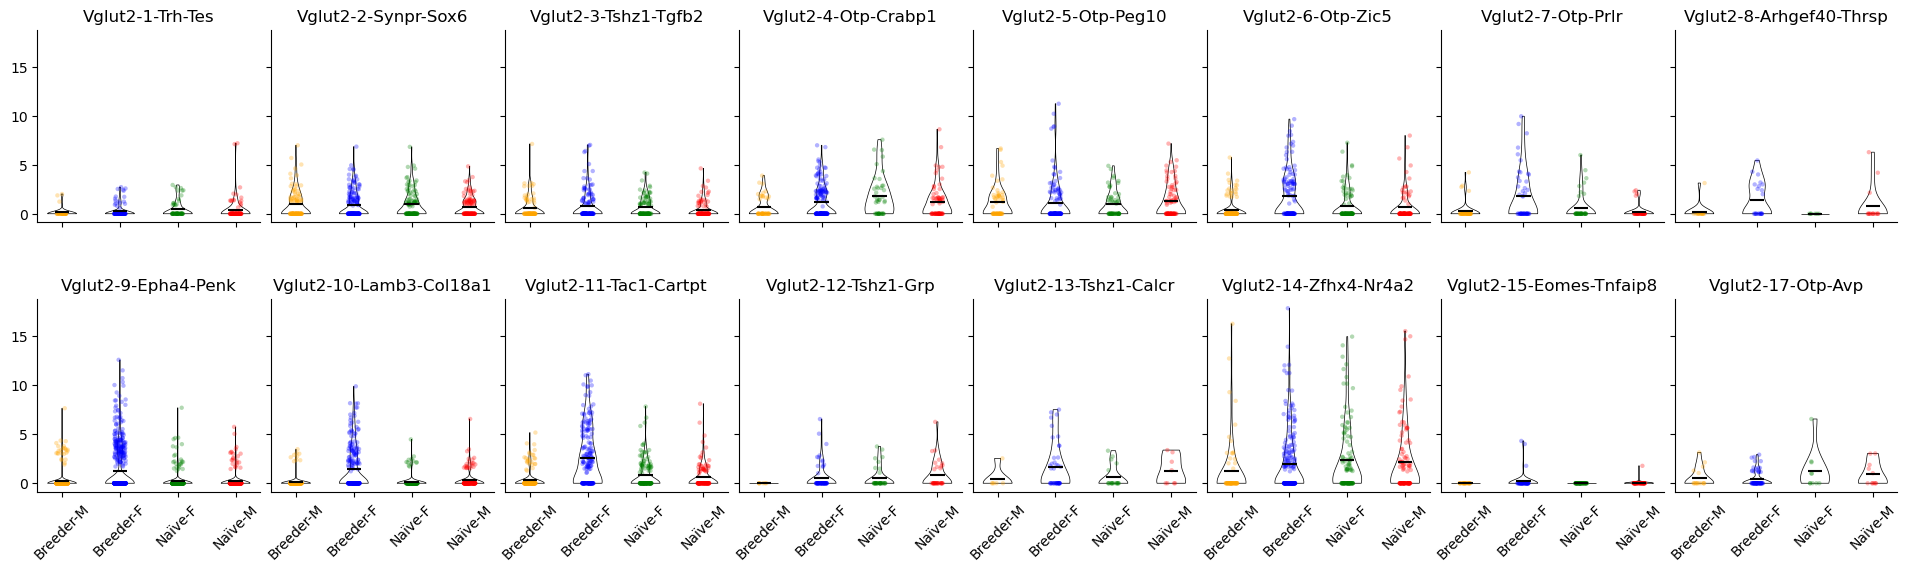

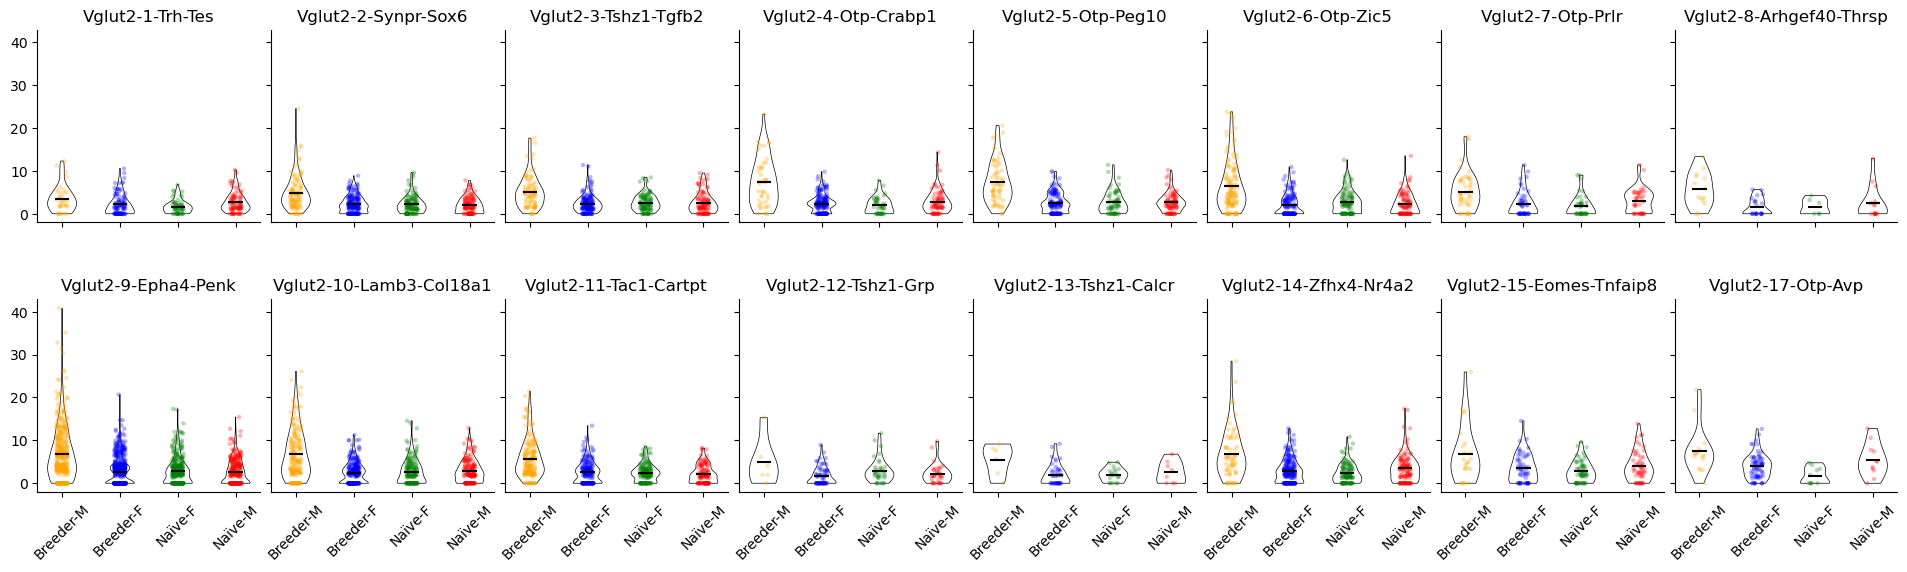

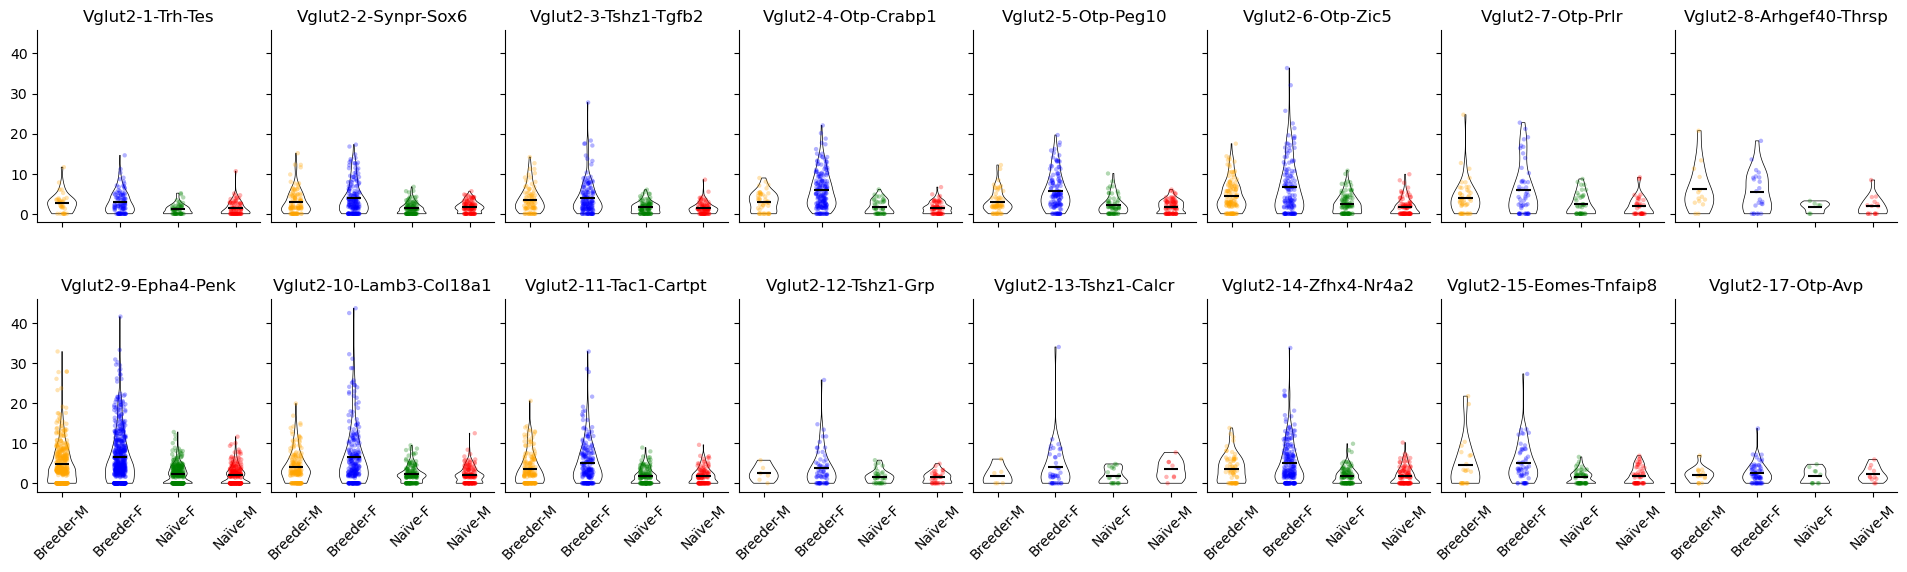

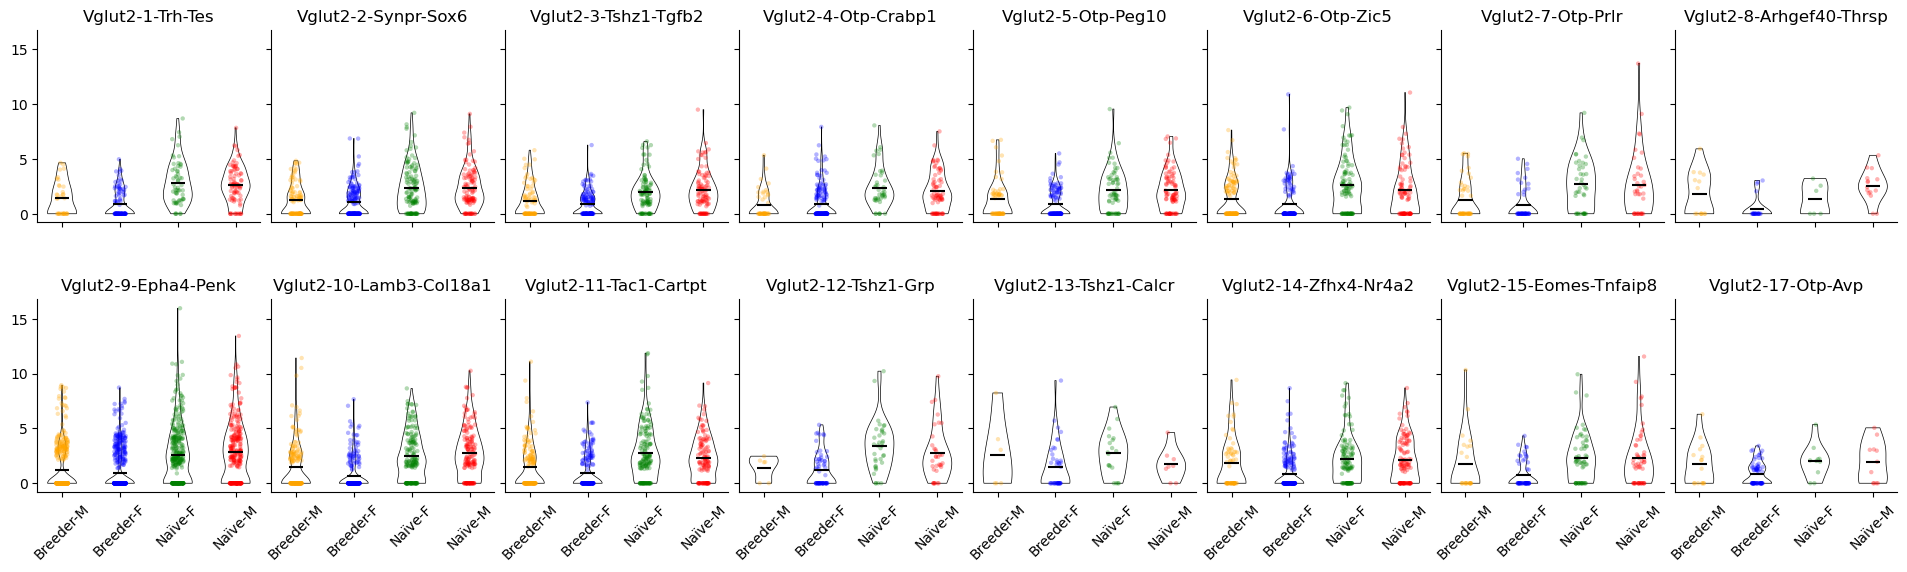

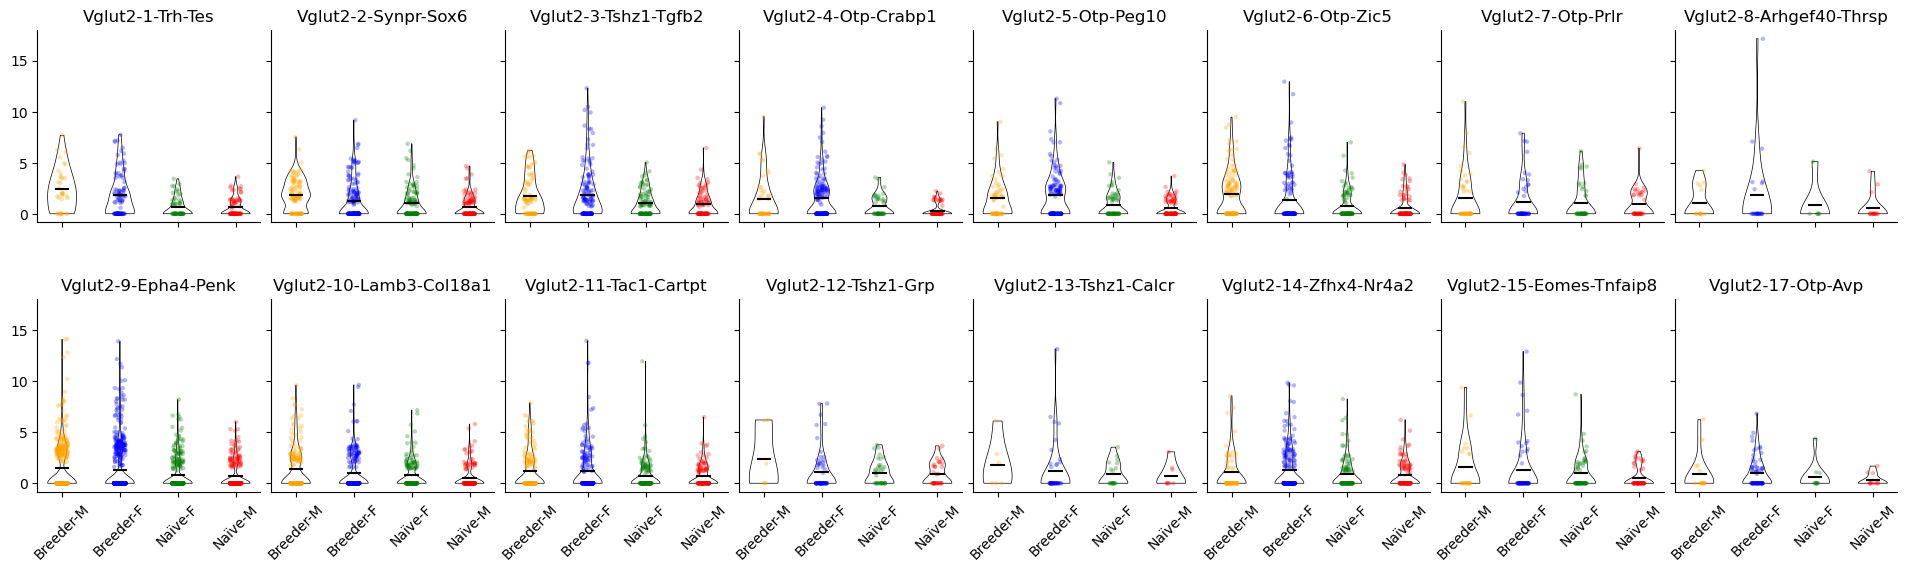

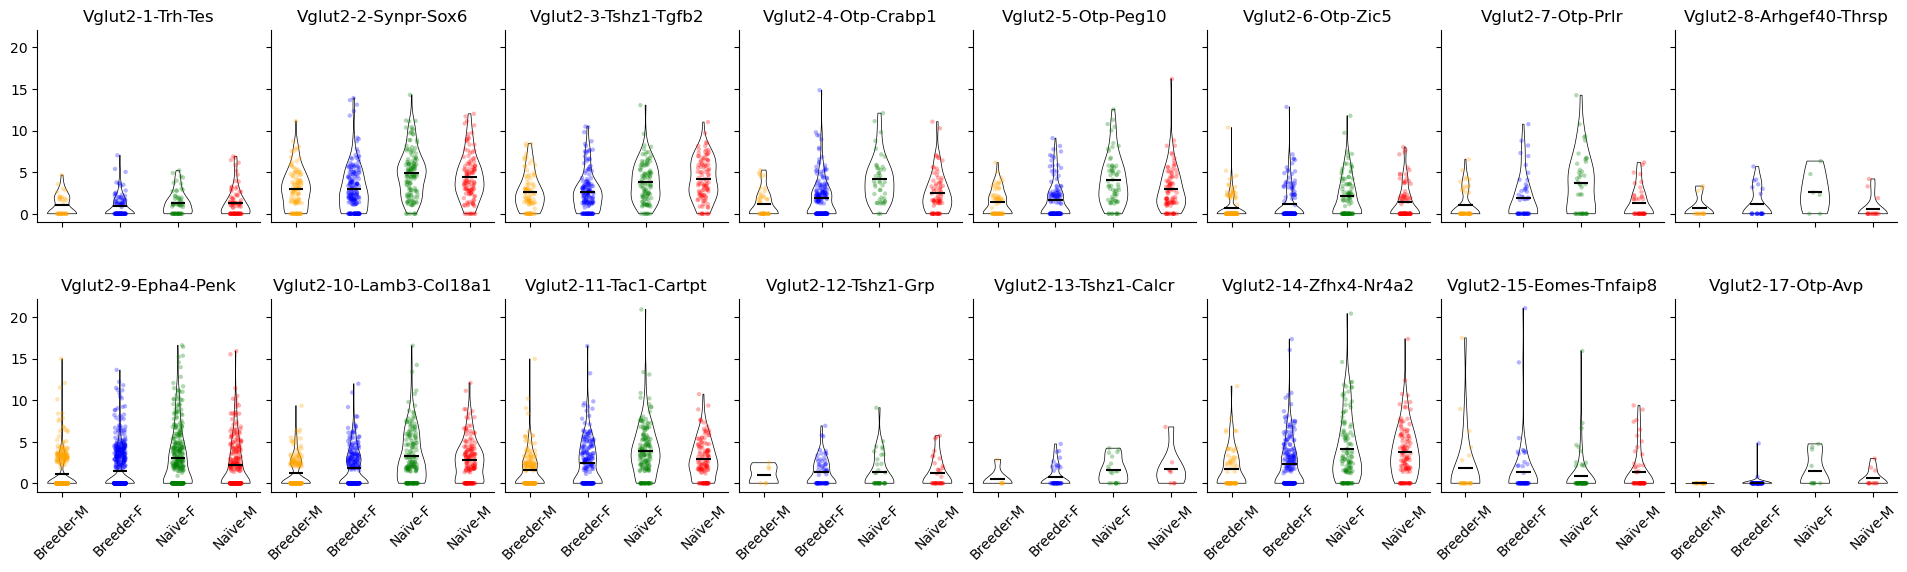

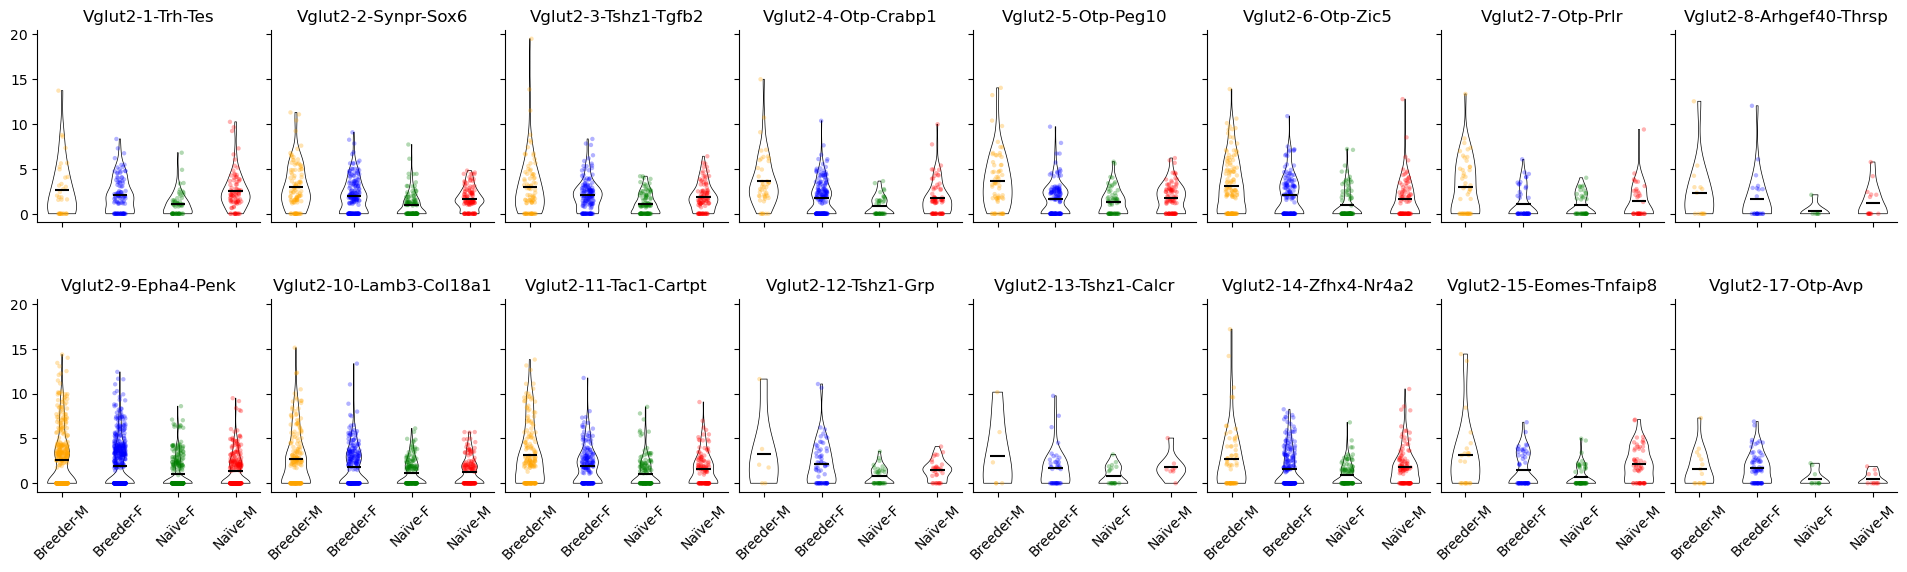

In [10]:
run = '200325_run'
cell_class = 'Vglut2'
outfolder = '/bigdata/isaac/top_gene_plots/'
full_names_vglut2 = [x for x in full_names if 'Vglut2' in x and x != 'Vglut2-16-Foxb1-Lhx1os']
#print (full_names_vglut2)
os.makedirs(outfolder, exist_ok=True)

N = len(full_names_vglut2)
#gene = 'Uba52'
for gene in gene_list:
    # Create a figure with N subplots in a horizontal layout
    fig, axes = plt.subplots(2, N//2, figsize=(3*(N//2), 6), sharey=True, sharex=True)
    #loop over a few cell types
    for i, ct in enumerate(full_names_vglut2):
        if i <N//2:
            b_m_expr,b_f_expr,n_f_expr,n_m_expr = vp.isolate_expression(ct,df_norm,meta_data_df)
            vp.plot_violin(gene,axes[0,i],ct,b_m_expr,b_f_expr,n_f_expr,n_m_expr,groups,outfolder, savefig = False)
        if i >= N//2:
            b_m_expr,b_f_expr,n_f_expr,n_m_expr = vp.isolate_expression(ct,df_norm,meta_data_df)
            vp.plot_violin(gene,axes[1,i-N//2],ct,b_m_expr,b_f_expr,n_f_expr,n_m_expr,groups,outfolder, savefig = False)
  
    os.makedirs(outfolder, exist_ok=True)
    plt.subplots_adjust(wspace=0.05)
    plt.subplots_adjust(hspace=0.4)
    plt.savefig(outfolder + gene + '_' + cell_class + '_2row' + '.png',bbox_inches="tight")
    #plt.show()

In [4]:
full_names_gaba

NameError: name 'full_names_gaba' is not defined

In [5]:
'Rps6ka6' in df_norm.index

True

In [4]:
full_names_nn = [x for x in full_names if 'Nonneuronal' in x]
full_names_nn

['Nonneuronal-1-OL_1',
 'Nonneuronal-2-OL_2',
 'Nonneuronal-3-OL_3',
 'Nonneuronal-4-Epend',
 'Nonneuronal-5-Astro_gfap',
 'Nonneuronal-6-Astro',
 'Nonneuronal-7-Proliferating_cells',
 'Nonneuronal-8-OPC',
 'Nonneuronal-9-Microglia',
 'Nonneuronal-10-Endothelial',
 'Nonneuronal-11-VSM']

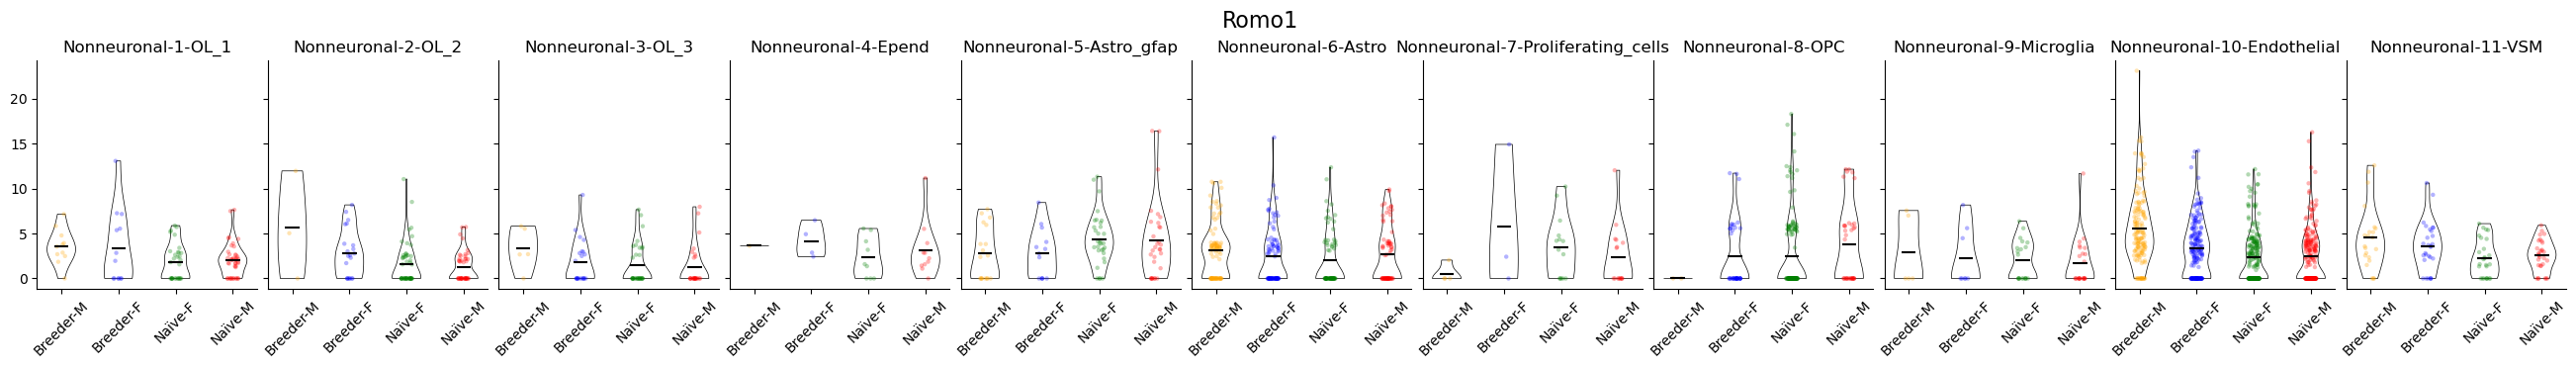

In [6]:
#check Rps6ka6 in NN
#per findingds from https://www.sciencedirect.com/science/article/pii/S0896627317308681?via%3Dihub
gene = 'Romo1'

run = '200325_run'
cell_class = 'NN'
outfolder = '/bigdata/isaac/top_gene_plots/'
full_names_nn = [x for x in full_names if 'Nonneuronal' in x]
os.makedirs(outfolder, exist_ok=True)
N = len(full_names_nn) #hard code


#print (f'plotting gene {gene} , {i} out of {len(gene_list)}')
# Create a figure with N subplots in a horizontal layout
fig, axes = plt.subplots(1, N, figsize=(3 * (N), 3), sharey=True, sharex=True)
#loop over a few cell types
for i, ct in enumerate(full_names_nn):
    b_m_expr,b_f_expr,n_f_expr,n_m_expr = vp.isolate_expression(ct,df_norm,meta_data_df)
    vp.plot_violin(gene,axes[i],ct,b_m_expr,b_f_expr,n_f_expr,n_m_expr,groups,outfolder, savefig = False)



os.makedirs(outfolder, exist_ok=True)
plt.subplots_adjust(wspace=0.05)
#plt.subplots_adjust(hspace=0.4)
fig.suptitle(gene, y = 1.05, fontsize=16)
plt.savefig(outfolder + gene + '_' + cell_class + '_3row' + '.png',bbox_inches="tight")
plt.show()
plt.close()

In [13]:
len(full_names_nn)

11